In [9]:
%run ../setup_env.py

Checking environment...
  ✓ faiss
  ✓ datasets
  ✓ evaluate
  ✓ accelerate
  ✓ sentencepiece

All packages present — ready to go
FAISS patch applied — version 1.14.1


In [12]:
import os
import sys
import json
import faiss
import torch
import numpy as np
import random
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import transformers.utils.import_utils as import_utils
import transformers.utils as tu

# faiss patch
if hasattr(import_utils.is_faiss_available, "cache_clear"):
    import_utils.is_faiss_available.cache_clear()
import_utils._faiss_available = True
import_utils.is_faiss_available = lambda: True
tu.is_faiss_available = lambda: True

REPO_ROOT      = os.path.abspath(os.path.join(os.getcwd(), "../.."))
FEVER_DIR      = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR       = os.path.join(FEVER_DIR, "data")
RESULTS_DIR    = os.path.join(FEVER_DIR, "results")
CONFIG_DIR     = os.path.join(FEVER_DIR, "configs")
CHECKPOINT_DIR = os.path.join(FEVER_DIR, "results", "checkpoints")

os.makedirs(RESULTS_DIR, exist_ok=True)

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

with open(os.path.join(CONFIG_DIR, "fever_config.yaml")) as f:
    config = yaml.safe_load(f)

LABEL2ID        = {"SUPPORTS": "0", "REFUTES": "1", "NOT ENOUGH INFO": "2"}
ID2LABEL        = {v: k for k, v in LABEL2ID.items()}
LABEL_TOKEN_IDS = [288, 134, 176]
MAX_LENGTH      = config["training"]["max_source_length"]

print(f"Fever dir:      {FEVER_DIR}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1024**3:.1f} GB")

Fever dir:      /home/jovyan/lectures/raq-reproducibility-challenge/fever
Checkpoint dir: /home/jovyan/lectures/raq-reproducibility-challenge/fever/results/checkpoints
GPU: NVIDIA A40
VRAM free: 18.7 GB


In [13]:
from datasets import load_dataset

print("Loading passages...")
passages = []
with open(os.path.join(DATA_DIR, "fever_passages.jsonl")) as f:
    for line in f:
        passages.append(json.loads(line))
print(f"Passages: {len(passages):,}")

print("Loading FAISS index → GPU...")
cpu_index = faiss.read_index(
    os.path.join(DATA_DIR, "fever_faiss.index")
)
res       = faiss.StandardGpuResources()
gpu_index = faiss.index_cpu_to_gpu(res, 0, cpu_index)
print(f"Index:    {gpu_index.ntotal:,} vectors on GPU")

print("Loading FEVER test set...")
dataset   = load_dataset("copenlu/fever_gold_evidence")
test_data = list(dataset["test"])
print(f"Test set: {len(test_data):,} examples")

# show test set distribution
test_labels = Counter(ex["label"] for ex in test_data)
print("\nTest set distribution:")
for label, count in test_labels.items():
    print(f"  {label}: {count:,} ({count/len(test_data)*100:.1f}%)")

Loading passages...
Passages: 574,197
Loading FAISS index → GPU...
Index:    574,197 vectors on GPU
Loading FEVER test set...
Test set: 16,039 examples

Test set distribution:
  NOT ENOUGH INFO: 6,456 (40.3%)
  REFUTES: 4,889 (30.5%)
  SUPPORTS: 4,694 (29.3%)


In [14]:
from transformers import (
    DPRQuestionEncoder,
    DPRQuestionEncoderTokenizerFast,
    BartForConditionalGeneration,
    BartTokenizer
)

print("Loading DPR question encoder...")
q_tokenizer = DPRQuestionEncoderTokenizerFast.from_pretrained(
    "facebook/dpr-question_encoder-single-nq-base"
)
q_encoder = DPRQuestionEncoder.from_pretrained(
    "facebook/dpr-question_encoder-single-nq-base"
).to("cuda")

print("Loading BART...")
bart_tokenizer = BartTokenizer.from_pretrained("facebook/bart-large")
model = BartForConditionalGeneration.from_pretrained(
    "facebook/bart-large"
).to("cuda")

# load best checkpoint — prefer GPU version
gpu_q    = os.path.join(CHECKPOINT_DIR, "q_encoder_best_gpu.pt")
gpu_bart = os.path.join(CHECKPOINT_DIR, "bart_best_gpu.pt")
cpu_q    = os.path.join(CHECKPOINT_DIR, "q_encoder_best.pt")
cpu_bart = os.path.join(CHECKPOINT_DIR, "bart_best.pt")

if os.path.exists(gpu_q):
    q_encoder.load_state_dict(torch.load(gpu_q,    map_location="cuda"))
    model.load_state_dict(    torch.load(gpu_bart,  map_location="cuda"))
    print("Loaded GPU best checkpoint (epoch 3)")
else:
    q_encoder.load_state_dict(torch.load(cpu_q,    map_location="cuda"))
    model.load_state_dict(    torch.load(cpu_bart,  map_location="cuda"))
    print("Loaded CPU best checkpoint")

q_encoder.eval()
model.eval()
print("Models in eval mode — ready")

Loading DPR question encoder...


Some weights of the model checkpoint at facebook/dpr-question_encoder-single-nq-base were not used when initializing DPRQuestionEncoder: ['question_encoder.bert_model.pooler.dense.bias', 'question_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRQuestionEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRQuestionEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Loading BART...
Loaded GPU best checkpoint (epoch 3)
Models in eval mode — ready


In [15]:
def search_index(claim, n_docs=config["model"]["n_docs"]):
    encoded = q_tokenizer(
        claim, return_tensors="pt",
        truncation=True, max_length=MAX_LENGTH
    )
    with torch.no_grad():
        query_vec = q_encoder(
            input_ids=encoded["input_ids"].to("cuda"),
            attention_mask=encoded["attention_mask"].to("cuda")
        ).pooler_output.cpu().numpy()
    query_norm = query_vec.copy()
    faiss.normalize_L2(query_norm)
    scores, indices = gpu_index.search(
        query_norm.astype("float32"), n_docs
    )
    return [
        {
            "rank":  i + 1,
            "score": float(scores[0][i]),
            "title": passages[indices[0][i]]["title"],
            "text":  passages[indices[0][i]]["text"],
            "idx":   int(indices[0][i])
        }
        for i in range(n_docs)
    ]


def forward_pass(claim, retrieved_results, gold_label_str):
    texts = [
        f"question: {claim} title: {p['title']} context: {p['text']}"
        for p in retrieved_results
    ]
    encoded = bart_tokenizer(
        texts, max_length=MAX_LENGTH,
        truncation=True, padding="max_length",
        return_tensors="pt"
    )
    K             = len(retrieved_results)
    gold_token_id = LABEL_TOKEN_IDS[int(LABEL2ID[gold_label_str])]
    labels        = torch.full((K, 1), gold_token_id)

    with torch.no_grad():
        output = model(
            input_ids      = encoded["input_ids"].to("cuda"),
            attention_mask = encoded["attention_mask"].to("cuda"),
            labels         = labels.to("cuda")
        )

    logits       = output.logits[:, 0, :]
    label_logits = logits[:, LABEL_TOKEN_IDS]
    retrieval_probs = torch.softmax(
        torch.tensor([r["score"] for r in retrieved_results]).to("cuda"),
        dim=0
    )
    marginalized = (
        retrieval_probs.unsqueeze(1) * label_logits
    ).sum(dim=0)
    return marginalized


print("Functions defined")

Functions defined


In [16]:
import time

print(f"Running evaluation on {len(test_data):,} test examples...")
print("Expected time: ~15-20 minutes\n")

gold_labels = []
pred_labels = []
all_probs   = []
t_start     = time.time()

for i, example in enumerate(test_data):
    if i % 1000 == 0:
        elapsed = time.time() - t_start
        remaining = (elapsed / max(i, 1)) * (len(test_data) - i)
        print(f"  {i:,}/{len(test_data):,} | "
              f"elapsed: {elapsed/60:.1f}min | "
              f"remaining: {remaining/60:.1f}min")

    results      = search_index(example["claim"])
    marginalized = forward_pass(
        example["claim"], results, example["label"]
    )

    probs      = torch.softmax(marginalized, dim=0)
    pred_idx   = torch.argmax(probs).item()
    pred_label = ID2LABEL[str(pred_idx)]

    gold_labels.append(example["label"])
    pred_labels.append(pred_label)
    all_probs.append(probs.cpu().numpy())

elapsed = time.time() - t_start
print(f"\nEvaluation complete in {elapsed/60:.1f} minutes")

Running evaluation on 16,039 test examples...
Expected time: ~15-20 minutes

  0/16,039 | elapsed: 0.0min | remaining: 0.0min
  1,000/16,039 | elapsed: 1.0min | remaining: 15.0min
  2,000/16,039 | elapsed: 2.0min | remaining: 14.0min
  3,000/16,039 | elapsed: 3.0min | remaining: 12.9min
  4,000/16,039 | elapsed: 4.0min | remaining: 11.9min
  5,000/16,039 | elapsed: 4.9min | remaining: 10.9min
  6,000/16,039 | elapsed: 5.9min | remaining: 9.9min
  7,000/16,039 | elapsed: 6.9min | remaining: 8.9min
  8,000/16,039 | elapsed: 7.9min | remaining: 7.9min
  9,000/16,039 | elapsed: 8.9min | remaining: 6.9min
  10,000/16,039 | elapsed: 9.9min | remaining: 6.0min
  11,000/16,039 | elapsed: 10.8min | remaining: 5.0min
  12,000/16,039 | elapsed: 11.8min | remaining: 4.0min
  13,000/16,039 | elapsed: 12.8min | remaining: 3.0min
  14,000/16,039 | elapsed: 13.8min | remaining: 2.0min
  15,000/16,039 | elapsed: 14.8min | remaining: 1.0min
  16,000/16,039 | elapsed: 15.7min | remaining: 0.0min

Evaluat

In [17]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# 3-way accuracy
acc_3way = accuracy_score(gold_labels, pred_labels)

# 2-way accuracy — filter out NEI
pairs_2way = [
    (g, p) for g, p in zip(gold_labels, pred_labels)
    if g != "NOT ENOUGH INFO"
]
gold_2way = [g for g, p in pairs_2way]
pred_2way = [p for g, p in pairs_2way]
acc_2way  = accuracy_score(gold_2way, pred_2way)

print("=" * 55)
print("FINAL TEST SET RESULTS")
print("=" * 55)
print(f"3-way accuracy: {acc_3way:.1%}  (paper: 72.5%)")
print(f"2-way accuracy: {acc_2way:.1%}  (paper: 89.5%)")
print(f"\nTest examples:  {len(test_data):,}")
print(f"2-way examples: {len(gold_2way):,} (excluding NEI)")

print("\n" + "=" * 55)
print("PER-CLASS REPORT")
print("=" * 55)
print(classification_report(
    gold_labels, pred_labels,
    target_names=["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"],
    digits=3
))

FINAL TEST SET RESULTS
3-way accuracy: 66.2%  (paper: 72.5%)
2-way accuracy: 75.1%  (paper: 89.5%)

Test examples:  16,039
2-way examples: 9,583 (excluding NEI)

PER-CLASS REPORT
                 precision    recall  f1-score   support

       SUPPORTS      0.714     0.531     0.609      6456
        REFUTES      0.749     0.664     0.704      4889
NOT ENOUGH INFO      0.572     0.841     0.681      4694

       accuracy                          0.662     16039
      macro avg      0.678     0.679     0.664     16039
   weighted avg      0.683     0.662     0.659     16039



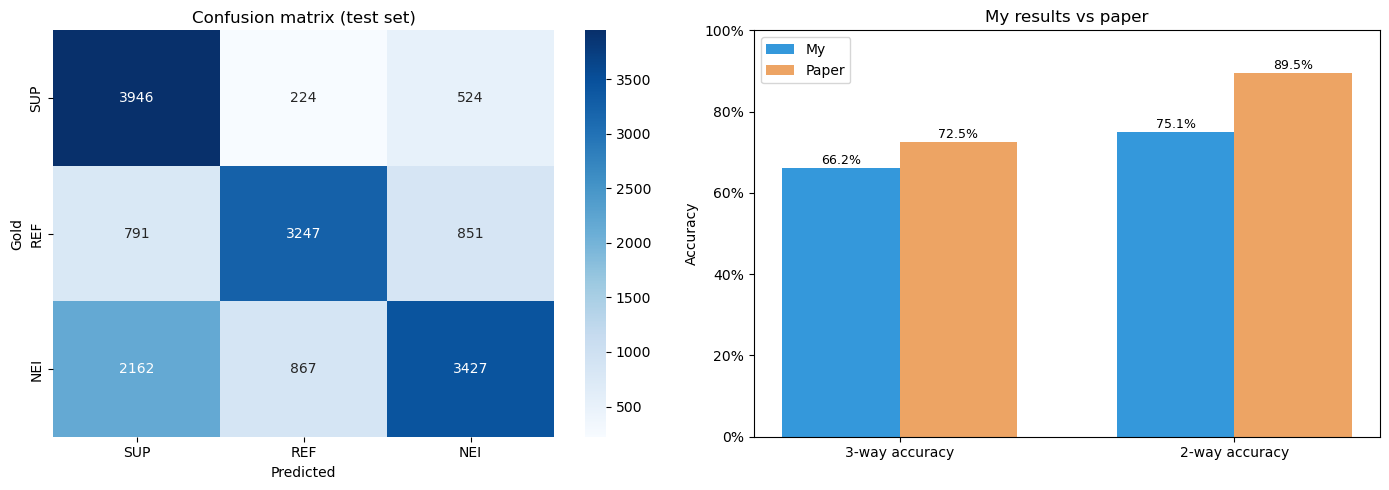

Plot saved


In [19]:
labels_order = ["SUPPORTS", "REFUTES", "NOT ENOUGH INFO"]
cm = confusion_matrix(gold_labels, pred_labels, labels=labels_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# confusion matrix
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["SUP", "REF", "NEI"],
    yticklabels=["SUP", "REF", "NEI"],
    cmap="Blues", ax=axes[0]
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Gold")
axes[0].set_title("Confusion matrix (test set)")

# accuracy comparison vs paper
categories  = ["3-way accuracy", "2-way accuracy"]
ours_vals   = [acc_3way, acc_2way]
paper_vals  = [0.725, 0.895]

x = np.arange(len(categories))
w = 0.35
axes[1].bar(x - w/2, ours_vals,  w, label="My",  color="#3498db")
axes[1].bar(x + w/2, paper_vals, w, label="Paper", color="#e67e22", alpha=0.7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("Accuracy")
axes[1].set_title("My results vs paper")
axes[1].legend()
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0%}")
)
for i, (o, p) in enumerate(zip(ours_vals, paper_vals)):
    axes[1].text(i - w/2, o + 0.01, f"{o:.1%}",
                 ha="center", fontsize=9)
    axes[1].text(i + w/2, p + 0.01, f"{p:.1%}",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.join(RESULTS_DIR, "final_evaluation.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved")